<a href="https://colab.research.google.com/github/venkata18167/CSA6301---THREAT-INTELLIGENCE-AND-NETWORK-SECURITY/blob/main/28_Static_and_Dynamic_Malware_Analysis_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== STATIC ANALYSIS ==========

        File Name       SHA256 Hash File Size (MB) Packed Malware Type
0      Trojan.exe  a1b2c3d4e5f67890            4.5    YES       Trojan
1  Ransomware.exe  b2c3d4e5f6789012            8.2    YES   Ransomware
2     Spyware.exe  c3d4e5f678901234            2.8     NO      Spyware
3      Adware.exe  d4e5f67890123456            1.9     NO       Adware
4        Worm.exe  e5f6789012345678            5.3    YES         Worm

========== DYNAMIC ANALYSIS ==========

        File Name  Registry Changes  Network Connections Suspicious Activity
0      Trojan.exe                15                    3                 YES
1  Ransomware.exe                52                   25                 YES
2     Spyware.exe                 8                    1                  NO
3      Adware.exe                 4                    0                  NO
4        Worm.exe                33                   12                 YES

========== RISK ASSESSMENT ====

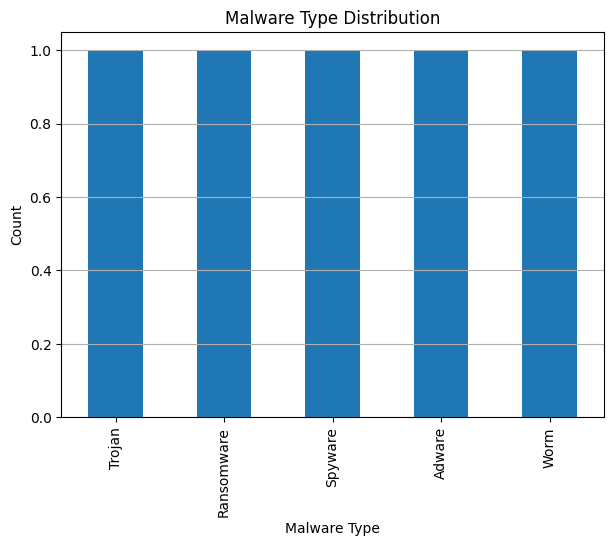


========== FINAL REPORT ==========
Total Files Analysed : 5
Packed Files : 3
Unpacked Files : 2
High Risk Samples : 1
Medium Risk Samples : 2
Low Risk Samples : 2

Simulation Completed Successfully.


In [1]:
 import pandas as pd
import matplotlib.pyplot as plt

malware = [

["Trojan.exe","a1b2c3d4e5f67890","4.5","YES","Trojan"],
["Ransomware.exe","b2c3d4e5f6789012","8.2","YES","Ransomware"],
["Spyware.exe","c3d4e5f678901234","2.8","NO","Spyware"],
["Adware.exe","d4e5f67890123456","1.9","NO","Adware"],
["Worm.exe","e5f6789012345678","5.3","YES","Worm"]

]

df = pd.DataFrame(
    malware,
    columns=[
        "File Name",
        "SHA256 Hash",
        "File Size (MB)",
        "Packed",
        "Malware Type"
    ]
)

print("========== STATIC ANALYSIS ==========\n")
print(df)

# Save static report
df.to_csv("Static_Analysis_Report.csv", index=False)

dynamic = [

["Trojan.exe",15,3,"YES"],
["Ransomware.exe",52,25,"YES"],
["Spyware.exe",8,1,"NO"],
["Adware.exe",4,0,"NO"],
["Worm.exe",33,12,"YES"]

]

runtime = pd.DataFrame(
    dynamic,
    columns=[
        "File Name",
        "Registry Changes",
        "Network Connections",
        "Suspicious Activity"
    ]
)

print("\n========== DYNAMIC ANALYSIS ==========\n")
print(runtime)

runtime.to_csv("Dynamic_Analysis_Report.csv", index=False)

risk = []

for i in range(len(runtime)):

    reg = runtime.loc[i,"Registry Changes"]
    net = runtime.loc[i,"Network Connections"]

    if reg >= 40 or net >= 20:
        level = "High"

    elif reg >= 15 or net >= 5:
        level = "Medium"

    else:
        level = "Low"

    risk.append(level)

runtime["Risk Level"] = risk

print("\n========== RISK ASSESSMENT ==========\n")
print(runtime)

runtime.to_csv("Malware_Risk_Report.csv", index=False)

stats = df["Malware Type"].value_counts()

print("\n========== MALWARE STATISTICS ==========\n")
print(stats)

plt.figure(figsize=(7,5))

stats.plot(kind="bar")

plt.title("Malware Type Distribution")
plt.xlabel("Malware Type")
plt.ylabel("Count")

plt.grid(axis="y")

plt.show()

print("\n========== FINAL REPORT ==========")

print("Total Files Analysed :", len(df))
print("Packed Files :", len(df[df["Packed"]=="YES"]))
print("Unpacked Files :", len(df[df["Packed"]=="NO"]))

print("High Risk Samples :", len(runtime[runtime["Risk Level"]=="High"]))
print("Medium Risk Samples :", len(runtime[runtime["Risk Level"]=="Medium"]))
print("Low Risk Samples :", len(runtime[runtime["Risk Level"]=="Low"]))

print("\nSimulation Completed Successfully.")